<a href="https://colab.research.google.com/github/alyplasc/climatedatascience/blob/main/HW_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import statsmodels.tsa.stattools as stattools

In [35]:
df = pd.read_csv('Paris_Tmax (2).csv', parse_dates=['time'],
                     index_col ='time')
df

,temperature_2m_max
time,
1950-01-01,5.203226
1950-02-01,9.950000
1950-03-01,11.322581
1950-04-01,13.083333
1950-05-01,18.735484
...,...
2026-02-01,11.910714
2026-03-01,14.003226
2026-04-01,18.980000


In [36]:
tmax = df['temperature_2m_max']

Question 8:

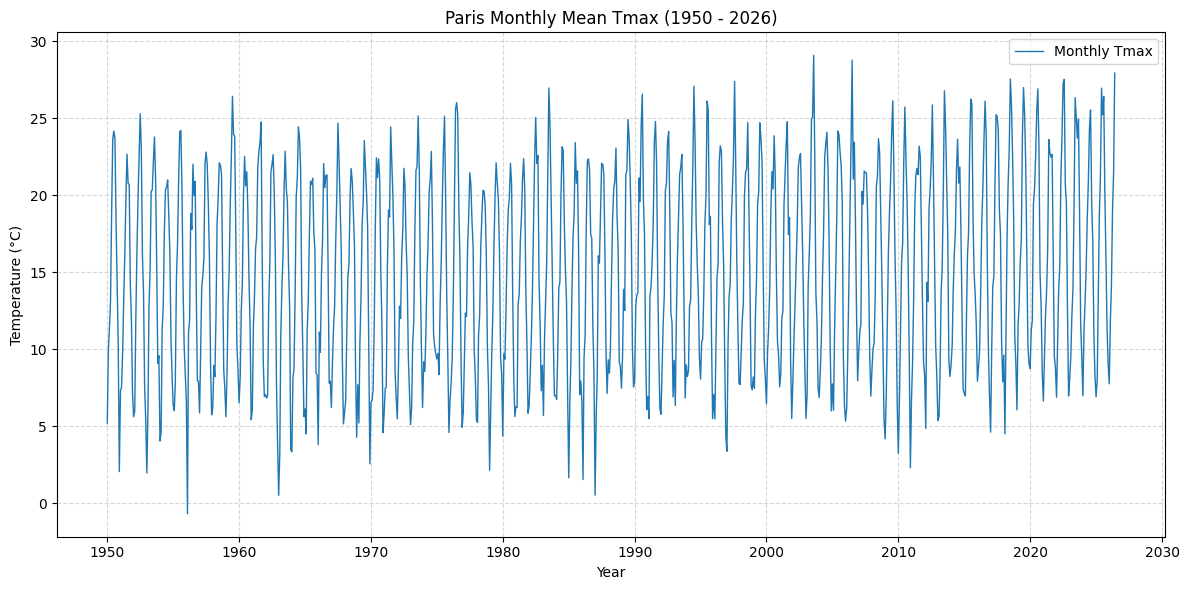

Mean of Paris Tmax: 14.9560 °C
Variance of Paris Tmax: 40.8564 °C²


In [37]:
import matplotlib.pyplot as plt

# Plot the time series of Paris monthly Tmax
plt.figure(figsize=(12, 6))
plt.plot(df.index, tmax, label='Monthly Tmax', color='tab:blue', linewidth=1)
plt.title('Paris Monthly Mean Tmax (1950 - 2026)')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Quantitatively describe the features by providing mean and variance
tmax_mean = tmax.mean()
tmax_var = tmax.var()

print(f"Mean of Paris Tmax: {tmax_mean:.4f} °C")
print(f"Variance of Paris Tmax: {tmax_var:.4f} °C²")

The Paris Tmax time series shows a strong annual seasonal cycle, with higher temperatures during the summer and lower temperatures during the winter. The data also show an overall warming trend over the record. The mean monthly Tmax is nearly 15 °C and the variance is around 41 °C².

### Question 9: Seasonal Cycle Estimation



In [38]:

# (a) Climatological Mean

climatological_mean = tmax.groupby(tmax.index.month).mean()

# (b) 12-Month Centered Running Mean

x = tmax.values
t_step = 12
n = len(x)
out = np.full(n, np.nan)
h = t_step // 2

for i in range(h, n - h):
    w = x[i-h:i+h+1].copy()
    w[0] *= 0.5
    w[-1] *= 0.5
    out[i] = w.sum() / t_step

centered_rm = pd.Series(out, index=tmax.index)
centered_rm.iloc[5:8]


,0
time,
1950-06-01,NaN
1950-07-01,14.662688
1950-08-01,14.648292


In [39]:
detrended = tmax - centered_rm
seasonal_anomaly = detrended.groupby(detrended.index.month).mean()
seasonal_anomaly.round(2)

,0
time,
1,-8.57
2,-7.12
3,-3.74
4,-0.63
5,3.13
6,6.36
7,8.51
8,8.40
9,5.38


In [40]:
running_mean_cycle = seasonal_anomaly + centered_rm.mean()
running_mean_cycle.round(2)

,0
time,
1,6.38
2,7.82
3,11.21
4,14.32
5,18.08
6,21.30
7,23.46
8,23.35
9,20.32


In [41]:
# (c) Results Table

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
harmonic = [6.4, 7.30, 10.3, 14.5, 18.8, 22.1, 23.5, 22.6, 19.7, 15.5, 11.2, 7.80]

results_df = pd.DataFrame({
    'Climatological': climatological_mean.values,
    'Running mean':   running_mean_cycle.values,
    'Harmonic':       harmonic
}, index=months).T



display(results_df.round(2))

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Climatological,6.37,7.89,11.24,14.36,18.12,21.42,23.45,23.35,20.33,15.82,10.19,7.07
Running mean,6.38,7.82,11.21,14.32,18.08,21.30,23.46,23.35,20.32,15.81,10.18,7.06
Harmonic,6.40,7.30,10.30,14.50,18.80,22.10,23.50,22.60,19.70,15.50,11.20,7.80


9c.  The climatological mean and 12-month centered running mean give very similar seasonal cycles. The harmonic fit is also similar, but differs more from the other two methods. The climatological mean is calculated separately for each calendar month, while the running mean smooths the data over a 12-month window.

### Question 10: Deseasonalized Data Analysis



In [42]:
climatological_mean_mapped = tmax.index.month.map(climatological_mean)
deseasonalized = tmax - climatological_mean_mapped

In [43]:
deseas_mean = deseasonalized.mean()
deseas_var = deseasonalized.var()

In [44]:
acf_values = stattools.acf(deseasonalized, nlags=5, adjusted=False)

In [45]:
print(f"Mean of deseasonalized data: {deseas_mean:.4f} °C")
print(f"Variance of deseasonalized data: {deseas_var:.3f} °C²")
print(f"Share of raw variance left: {100*deseas_var/tmax_var:.1f}%")

acf_table = pd.DataFrame({'ACF': acf_values[1:6]}, index=[1, 2, 3, 4, 5]).T
acf_table.columns.name = 'Lag'
display(acf_table.round(3))

print(f"95% significance threshold 1.96/sqrt(n) = {1.96/np.sqrt(len(deseasonalized)):.3f}")

Mean of deseasonalized data: 0.0000 °C
Variance of deseasonalized data: 3.626 °C²
Share of raw variance left: 8.9%


Lag,1,2,3,4,5
ACF,0.311,0.226,0.218,0.171,0.167


95% significance threshold 1.96/sqrt(n) = 0.065


### Question 11: Linear Trend and Decadal Warming Rate


In [46]:
t = (deseasonalized.index.year + (deseasonalized.index.month - 0.5) / 12).values
y = deseasonalized.values
n = len(y)
print(t[:3], t[-1], n)

[1950.04166667 1950.125      1950.20833333] 2026.4583333333333 918


In [47]:
b, a = np.polyfit(t, y, 1)
print(f"slope = {b:.5f} °C/year = {b*10:.3f} °C/decade")

slope = 0.03182 °C/year = 0.318 °C/decade


In [48]:
# Standard Error
e = y - (a + b * t)

S = np.sum((t - t.mean())**2)
sigma_hat = np.sqrt(np.sum(e**2) / (n - 2))
se_naive = sigma_hat / np.sqrt(S)
print(f"sigma_hat = {sigma_hat:.3f} °C, SE = {se_naive*10:.4f} °C/decade")

sigma_hat = 1.771 °C, SE = 0.0265 °C/decade


In [49]:
# Confidence Interval
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, n - 2)
ci_naive = t_crit * se_naive
print(f"t_crit = {t_crit:.3f}")
print(f"95% CI (independent): {b*10:.3f} ± {ci_naive*10:.3f} "
      f"→ [{(b-ci_naive)*10:.3f}, {(b+ci_naive)*10:.3f}] °C/decade")

t_crit = 1.963
95% CI (independent): 0.318 ± 0.052 → [0.266, 0.370] °C/decade


In [50]:
r1 = stattools.acf(e, nlags=1, adjusted=False)[1]
threshold = 1.96 / np.sqrt(n)
print(f"r1 = {r1:.3f}, threshold = {threshold:.3f}")

r1 = 0.205, threshold = 0.065


In [51]:
#effective sample size CI

n_eff = n * (1 - r1) / (1 + r1)
se_eff = se_naive * np.sqrt(n / n_eff)
t_crit_eff = stats.t.ppf(1 - alpha/2, n_eff - 2)
ci_eff = t_crit_eff * se_eff
p_eff = 2 * stats.t.sf(abs(b / se_eff), n_eff - 2)

print(f"n_eff = {n_eff:.0f} (instead of {n})")
print(f"SE inflation factor = {np.sqrt(n/n_eff):.3f}")
print(f"95% CI (AR1): {b*10:.3f} ± {ci_eff*10:.3f} "
      f"→ [{(b-ci_eff)*10:.3f}, {(b+ci_eff)*10:.3f}] °C/decade")
print(f"p-value = {p_eff:.2g}")

n_eff = 606 (instead of 918)
SE inflation factor = 1.231
95% CI (AR1): 0.318 ± 0.064 → [0.254, 0.382] °C/decade
p-value = 4.9e-21


Q11:
- The linear warming trend in the deseasonalized data is 0.03182 °C/year, or approximately 0.318 °C/decade.
- The 95% confidence interval is 0.266–0.370 °C/decade. However, the residuals have positive lag-1 autocorrelation, so the observations are not completely independent.

- When accounting for the lag 1 autocorrelation, the 95% confidence interval is 0.254–0.382 °C/decade. Therefore, accounting for autocorrelation matters because it increases the uncertainty around the estimated warming rate, but the estimated trend itself remains the same.

##Concept Questions

###Q1:
a. Stationary process is a time series whose mean and variance are constant over
time, and whose autocovariance depends only on the lag between two points, not
on time itself.

b. Time-domain methods seek to characterize time-series data in the same terms in which they are observe

e. When data points are correlated, each new one carries less new information

##Q2

a. The variance of the mean, without considering serial correlation, is 0.35.

d. The effective sample size is 11.1, and the variance of the mean, accounting for serial correlation, is 3.15.

##Q3

a) A low-pass filter is a filter that passes signals with a frequency lower than a selected cut-off frequency. It removes high frequency noise like a running mean.

A high-pass filter is the opposite and attenuates signals below a cutoff frequency.

A band-pass filter is a filter that passes frequencies within a certain range and attentuates frequencies outside this range.


b) A strong seasonal cycle makes autocorrelation because values are tend to be similar during the same time of the year due to season. The biggest spike happens at 12-month because the months will line up with the last year.



c)A power spectrum measures and represents the variance of a time series distributed over different frequencies.



##Q4

a) Line 1 is the PDO (20-30 year phases). Line 2 has the slowest pattern and is the AMO (50-70 year phases).
Line 3 is the RONI becuase it has shorter cycles (2-7 year phases).

b) Taller and more narrow peaks have more regular period like AMO in line 2. The shorter and wider peaks are more varied and this corresponds to PDO in line 1.

#Q5


Since Yt is normally distributed and Xt = Yt + Tt, Xt is also normally distributed.

The mean of Xt is:

E[Xt] = T0 + kt

The variance is:

Var[Xt] = sigma_w^2 * (1 - phi^(2t)) / (1 - phi^2)

Using the values given in the problem:

Xt ~ N(25 + 0.001t, 0.01 * (1 - phi^(2t)) / (1 - phi^2))



## Q6

phi = 0.75.

The forecast mean is:

E[Xt] = 25 + 0.001t

The 95% interval is calculated as:

mean +/- 1.96 * standard deviation

In [52]:
## a) t=1
phi = 0.75
t = 1

mean_1 = 25 + 0.001*t
var_1 = 0.01 * (1 - phi**(2*t)) / (1 - phi**2)
std_1 = np.sqrt(var_1)

lower_1 = mean_1 - 1.96*std_1
upper_1 = mean_1 + 1.96*std_1

print(mean_1, lower_1, upper_1)

25.001 24.805 25.197000000000003


In [53]:
## b) t=3

phi = 0.75
t = 3

mean_3 = 25 + 0.001*t
var_3 = 0.01 * (1 - phi**(2*t)) / (1 - phi**2)
std_3 = np.sqrt(var_3)

lower_3 = mean_3 - 1.96*std_3
upper_3 = mean_3 + 1.96*std_3

print(mean_3, lower_3, upper_3)

25.003 24.7343365255566 25.2716634744434


## Q7

As t approaches infinity, phi^(2t) approaches 0 as long as |phi| < 1.Therefore, the variance approaches: sigma_w^2 / (1 - phi^2) Using phi = 0.75 and sigma_w^2 = 0.01: 0.01 / (1 - 0.75^2) = 0.0229 Therefore: Yt approaches N(0, 0.0229) This means that the variance approaches a stable value instead of continuing to increase.